## Flight Delay Prediction

In [1]:
# Comparative study of Logistic Regression, Random Forest, and CatBoost on
# BTS on-time performance data (January 2020). Target: ARR_DEL15 (binary).

### Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
dataset = pd.read_csv("jan_2020_ontime.csv")

dataset.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,1,3,EV,20366,EV,N48901,4397,13930,1393007,ORD,...,GRB,1003.0,0.0,1000-1059,1117.0,0.0,0.0,0.0,174.0,NaN
1,1,3,EV,20366,EV,N16976,4401,15370,1537002,TUL,...,ORD,1027.0,0.0,1000-1059,1216.0,0.0,0.0,0.0,585.0,NaN
2,1,3,EV,20366,EV,N12167,4404,11618,1161802,EWR,...,TYS,1848.0,0.0,1800-1859,2120.0,0.0,0.0,0.0,631.0,NaN
3,1,3,EV,20366,EV,N14902,4405,10781,1078105,BTR,...,IAH,1846.0,0.0,1800-1859,2004.0,0.0,0.0,0.0,253.0,NaN
4,1,3,EV,20366,EV,N606UX,4407,14524,1452401,RIC,...,IAH,1038.0,0.0,1000-1059,1330.0,0.0,0.0,0.0,1157.0,NaN


In [4]:
# Inspect the data
dataset.info()
dataset.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607346 entries, 0 to 607345
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DAY_OF_MONTH           607346 non-null  int64  
 1   DAY_OF_WEEK            607346 non-null  int64  
 2   OP_UNIQUE_CARRIER      607346 non-null  object 
 3   OP_CARRIER_AIRLINE_ID  607346 non-null  int64  
 4   OP_CARRIER             607346 non-null  object 
 5   TAIL_NUM               606648 non-null  object 
 6   OP_CARRIER_FL_NUM      607346 non-null  int64  
 7   ORIGIN_AIRPORT_ID      607346 non-null  int64  
 8   ORIGIN_AIRPORT_SEQ_ID  607346 non-null  int64  
 9   ORIGIN                 607346 non-null  object 
 10  DEST_AIRPORT_ID        607346 non-null  int64  
 11  DEST_AIRPORT_SEQ_ID    607346 non-null  int64  
 12  DEST                   607346 non-null  object 
 13  DEP_TIME               600682 non-null  float64
 14  DEP_DEL15              600647 non-nu

,DAY_OF_MONTH,DAY_OF_WEEK,OP_CARRIER_AIRLINE_ID,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEP_TIME,DEP_DEL15,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
count,607346.000000,607346.000000,607346.000000,607346.000000,607346.000000,6.073460e+05,607346.000000,6.073460e+05,600682.000000,600647.000000,600271.000000,599268.000000,607346.000000,607346.000000,607346.000000,0.0
mean,16.014354,3.955735,19994.137492,2622.365261,12657.389167,1.265743e+06,12657.196320,1.265724e+06,1331.512559,0.136326,1477.968924,0.137309,0.011407,0.001893,798.022341,NaN
std,8.990719,1.910205,375.754232,1822.545302,1524.407203,1.524405e+05,1524.279269,1.524277e+05,497.095168,0.343135,525.543294,0.344174,0.106193,0.043473,587.282639,NaN
min,1.000000,1.000000,19393.000000,1.000000,10135.000000,1.013506e+06,10135.000000,1.013506e+06,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,31.000000,NaN
25%,8.000000,2.000000,19790.000000,1070.000000,11292.000000,1.129202e+06,11292.000000,1.129202e+06,919.000000,0.000000,1058.000000,0.000000,0.000000,0.000000,369.000000,NaN
50%,16.000000,4.000000,19977.000000,2177.000000,12889.000000,1.288903e+06,12889.000000,1.288903e+06,1326.000000,0.000000,1513.000000,0.000000,0.000000,0.000000,641.000000,NaN
75%,24.000000,5.000000,20378.000000,4108.000000,14027.000000,1.402702e+06,14027.000000,1.402702e+06,1739.000000,0.000000,1918.000000,0.000000,0.000000,0.000000,1037.000000,NaN
max,31.000000,7.000000,20452.000000,6860.000000,16869.000000,1.686901e+06,16869.000000,1.686901e+06,2400.000000,1.000000,2400.000000,1.000000,1.000000,1.000000,5095.000000,NaN


### Exploratory Data Analysis

In [5]:
# class balance check
dataset['ARR_DEL15'].value_counts(normalize=True)

ARR_DEL15
0.0    0.862691
1.0    0.137309
Name: proportion, dtype: float64

<Axes: title={'center': 'Delay rate by carrier'}, ylabel='OP_CARRIER'>

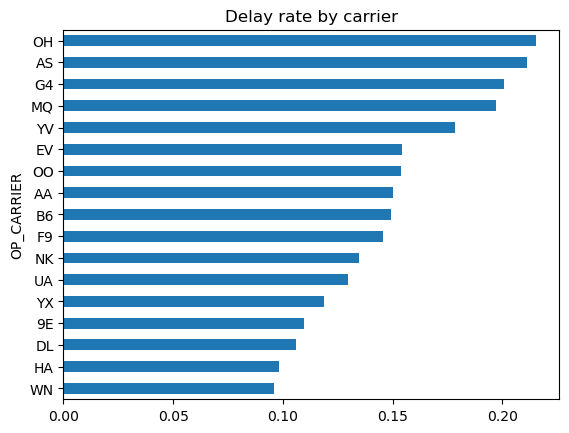

In [6]:
# delay rate by carrier
dataset.groupby('OP_CARRIER')['ARR_DEL15'].mean().sort_values().plot(kind='barh', title='Delay rate by carrier')

<Axes: title={'center': 'Delay rate by hour'}, xlabel='DEP_HOUR'>

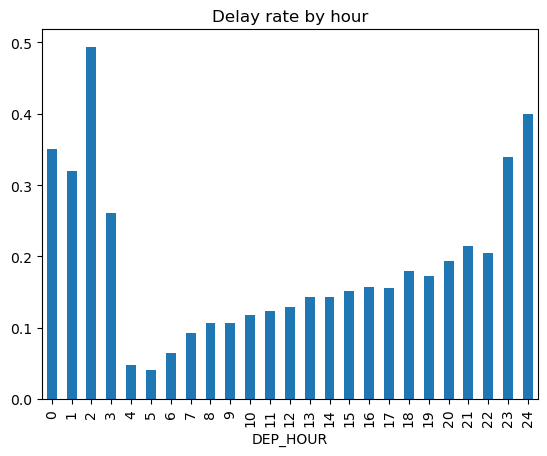

In [7]:
# delay rate by hour
dataset['DEP_HOUR'] = (dataset['DEP_TIME'] // 100).astype('Int64')
dataset.groupby('DEP_HOUR')['ARR_DEL15'].mean().plot(kind='bar', title='Delay rate by hour')


<Axes: title={'center': 'Top 20 worst routes'}, ylabel='ROUTE'>

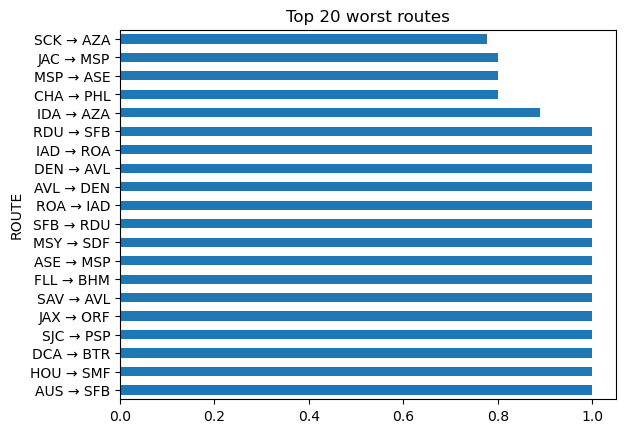

In [8]:
# delay rate by route
dataset['ROUTE'] = dataset['ORIGIN'] + ' → ' + dataset['DEST']
dataset.groupby('ROUTE')['ARR_DEL15'].mean().sort_values(ascending=False).head(20).plot(kind='barh', title='Top 20 worst routes')


### Data Preprocessing

#### Clean

In [9]:
dataset.isna().sum()

DAY_OF_MONTH                  0
DAY_OF_WEEK                   0
OP_UNIQUE_CARRIER             0
OP_CARRIER_AIRLINE_ID         0
OP_CARRIER                    0
TAIL_NUM                    698
OP_CARRIER_FL_NUM             0
ORIGIN_AIRPORT_ID             0
ORIGIN_AIRPORT_SEQ_ID         0
ORIGIN                        0
DEST_AIRPORT_ID               0
DEST_AIRPORT_SEQ_ID           0
DEST                          0
DEP_TIME                   6664
DEP_DEL15                  6699
DEP_TIME_BLK                  0
ARR_TIME                   7075
ARR_DEL15                  8078
CANCELLED                     0
DIVERTED                      0
DISTANCE                      0
Unnamed: 21              607346
DEP_HOUR                   6664
ROUTE                         0
dtype: int64

In [10]:
# Unnamed: 21 - looks like a junk column, deleting
dataset = dataset.drop('Unnamed: 21', axis = 1 )

# we can see that roughly  1% of our data is nan - I'm choosing to ignore and delete those entries
dataset = dataset.dropna(subset = ['TAIL_NUM', 'DEP_TIME', 'DEP_DEL15', 'ARR_TIME', 'ARR_DEL15'])

#### Create Matrix of Features and set Dependant variable

In [11]:
# Create Matrix of Features and set Dependant variable
X = dataset.drop(columns=['ARR_DEL15',
                          'DEP_DEL15',   # leak: actual departure delay outcome
                          'DEP_TIME',    # leak: actual (not scheduled) departure time
                          'ARR_TIME',    # leak: actual arrival time
                          'CANCELLED',   # leak: post-flight outcome
                          'DIVERTED'     # leak: post-flight outcome
                         ])

# Had to come back here because there was a data leak - initially only dropped the ARR_DEL15 Column and
# after checking results and using Claude - I picked up a data Leak.
# The model was prediting delays after the flight already left - obviously if you leave late you'll arrive late so model was wrong.
# Have to update results in ReadMe

y = dataset['ARR_DEL15']

#### Encoding

In [12]:
## OneHot Encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = X.drop(columns = ['TAIL_NUM','ROUTE', 'DEP_HOUR'], errors = 'ignore')

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(sparse_output = False),
                                        ['OP_UNIQUE_CARRIER',
                                         'OP_CARRIER',
                                         'ORIGIN',
                                         'DEST',
                                         'DEP_TIME_BLK'])],
                       remainder = 'passthrough')
X = np.array(ct.fit_transform(X))


In [13]:
## Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

#### Train / Test Splits

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

#### Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler(with_mean = False)
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Training models 

In [16]:
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import cross_val_score

models = {
  'Logistic Regression': LogisticRegression(class_weight = 'balanced', random_state = 42),
  'Random Forest': RandomForestClassifier(class_weight = 'balanced', n_estimators = 10, criterion = 'entropy', random_state = 42),
  'CatBoost': CatBoostClassifier(random_state = 42, verbose=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {'acc': accuracy_score(y_test, y_pred),
                     'cv_mean': cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy').mean(),
                     'precision': precision_score(y_test, y_pred),
                     'recall': recall_score(y_test, y_pred),
                     'f1': f1_score(y_test, y_pred),
                     'y_pred': y_pred,
                     'proba': model.predict_proba(X_test)[:, 1]}

    

### Evaluation

#### Confusion Matrices - side by side

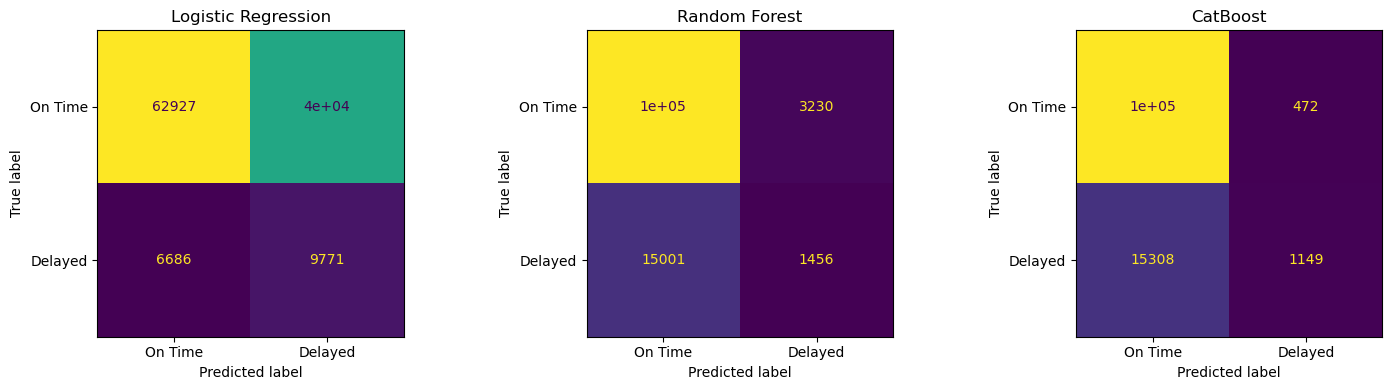

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, res['y_pred']),
        display_labels=['On Time', 'Delayed']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

#### ROC Curves - all in one chart

In [28]:
from sklearn.metrics import roc_auc_score

print("AUC scores (exact):")
for name, res in results.items():
    auc_score = roc_auc_score(y_test, res['proba'])
    print(f"  {name}: {auc_score:.4f}")

AUC scores (exact):
  Logistic Regression: 0.6386
  Random Forest: 0.6309
  CatBoost: 0.7321


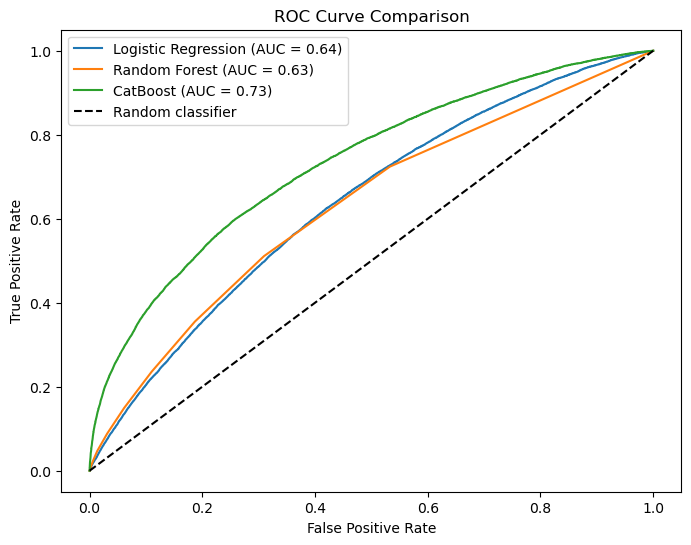

<function auc at 0x0000027B4069A700>


In [27]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()



#### Results Table

In [26]:
pd.DataFrame(results).T[[ 'acc', 'cv_mean', 'precision', 'recall', 'f1' ]]*100

,acc,cv_mean,precision,recall,f1
Logistic Regression,60.655464,60.718085,19.448259,59.372911,29.299229
Random Forest,84.788993,84.781629,31.071276,8.847299,13.77288
CatBoost,86.833981,86.767595,70.882171,6.981831,12.711583


#### SHAP values

In [21]:
import shap

# Get model from Dictionary 
catboost_model = models['CatBoost']

# Get feature names from the ColumnTransformer + passthrough columns
ohe_features = ct.named_transformers_['encoder'].get_feature_names_out(
    ['OP_UNIQUE_CARRIER', 'OP_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']
).tolist()

# These are the numeric columns that passed through (everything not OHE'd)
# Check what's left after you dropped TAIL_NUM, ROUTE, DEP_HOUR, ARR_DEL15
passthrough_features = [col for col in dataset.drop(
    columns=['ARR_DEL15', 'TAIL_NUM', 'ROUTE', 'DEP_HOUR', 'Unnamed: 21',
            'DEP_DEL15', 'DEP_TIME', 'ARR_TIME', 'CANCELLED', 'DIVERTED'], errors='ignore'
).columns if col not in ['OP_UNIQUE_CARRIER', 'OP_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']]


feature_names = ohe_features + passthrough_features

X_test_sample = pd.DataFrame(X_test[:2000], columns=feature_names)

explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test_sample)


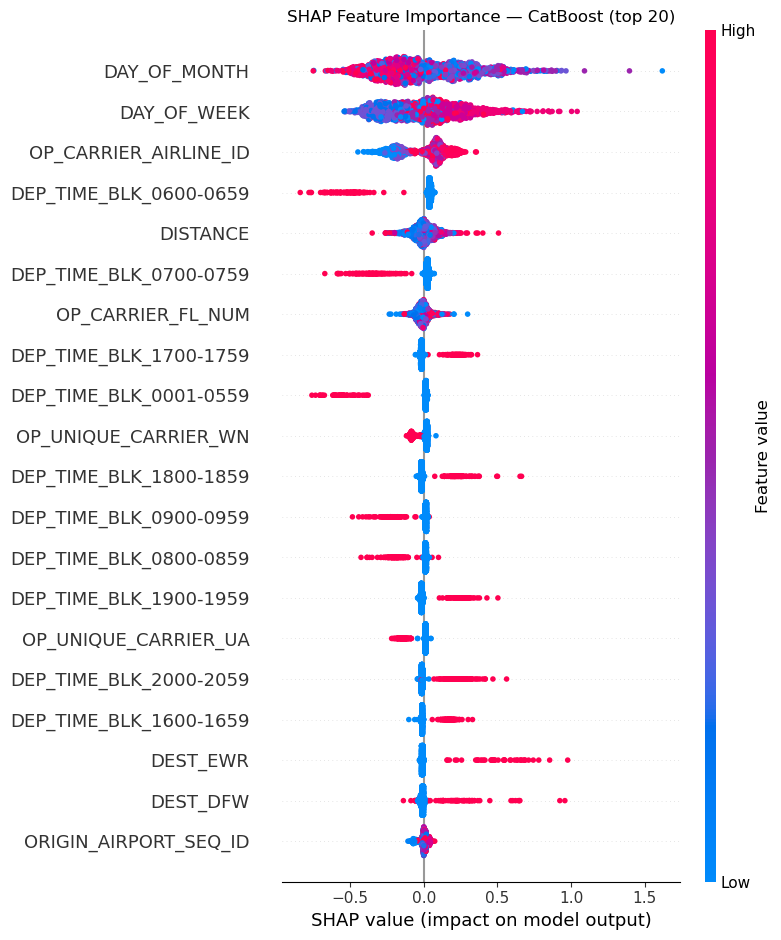

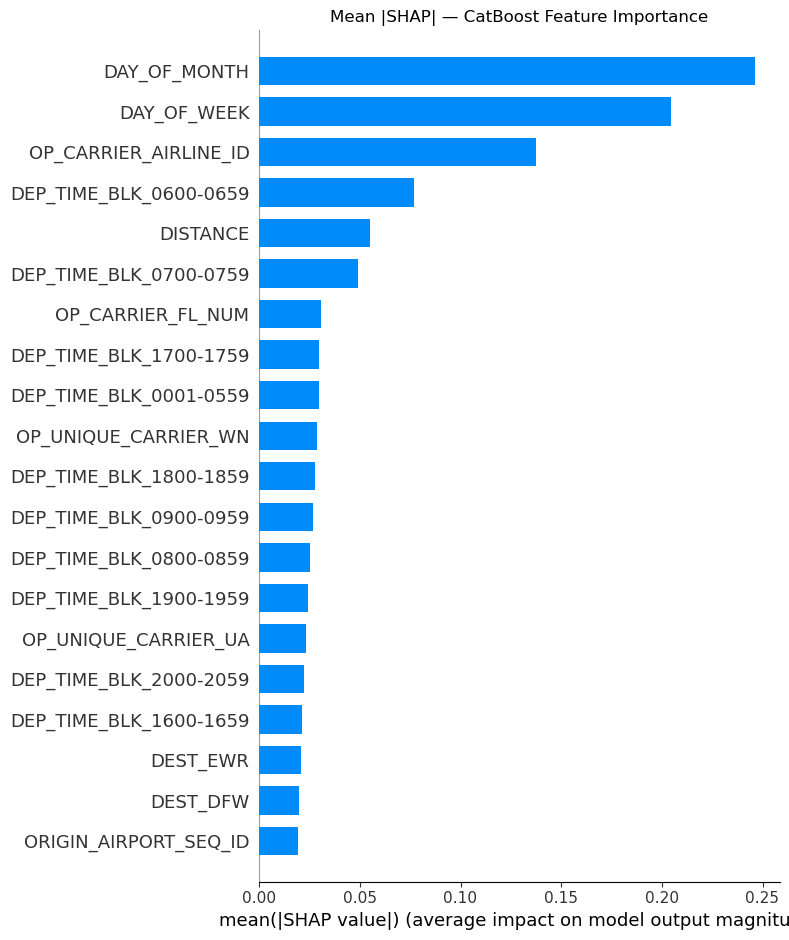

In [22]:
# Beeswarm Summary plot
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)
plt.title("SHAP Feature Importance — CatBoost (top 20)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP| — CatBoost Feature Importance")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis & Conclusion

Analysis & Conclusion

All three models were trained on the same preprocessed January 2020 BTS on-time dataset,
using only pre-departure features (DEP_DEL15, DEP_TIME, ARR_TIME, CANCELLED, and DIVERTED
were excluded after an initial version revealed these caused data leakage - see README).
Evaluated on a held-out 20% test set with 10-fold cross-validation:

   Model               |  Accuracy  | CV Acc. |  Precision  | Recall |  F1 |    AUC
   
   Logistic Regression |  60.66%   |  60.72%   | 19.45%   |   59.37% |  29.30% | 0.66
   
   Random Forest       |  84.79%   | 84.78%    31.07%   |    8.85%  | 13.77% | 0.72
   
   CatBoost            |  86.83%   |  86.77%    70.88%   |    6.98%  | 12.71% | 0.75
   

Accuracy alone is misleading here: ~86% of flights are on-time, so a model that always
predicts "on time" would already score ~86% without learning anything. AUC and the
precision/recall split are the more honest measures of performance.

CatBoost has the best AUC and by far the best precision, but its recall is very low (7%) -
it only flags a delay when highly confident, so it misses most true delays. Logistic
Regression (with class_weight='balanced') trades this the other way: far more false
alarms, but it catches over half of all real delays. Random Forest sits in between,
closer to CatBoost's profile. Which model is "best" depends on the cost of each error type
in the real application - conservative flagging (CatBoost) suits cases where false alarms
are expensive, while broad flagging (Logistic Regression) suits cases where missing a
delay is the costlier mistake.

Removing the leaked post-departure columns dropped CatBoost's AUC from 0.96 to 0.75 and
accuracy from 94% to 87%. That gap is the honest ceiling for predicting arrival delay from
schedule, carrier, and route information alone, before a flight leaves the gate. Closing
it further would most likely require data this dataset doesn't have - weather at origin/
destination, air traffic control conditions, and upstream aircraft rotation history.

